# Bayesian optimization validation notebook

This notebook mirrors the website's starter case: choose `temperature` and `pressure`, maximize `yield`, and keep `median` close to 10. It loads `sample_bo_starting_points.csv`, fits one Gaussian-process surrogate per output, and ranks unmeasured grid points with a confidence-bound acquisition score.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import MinMaxScaler

CSV_PATH = Path('sample_bo_starting_points.csv')
INPUTS = {
    'temperature': {'min': 200, 'max': 300, 'step': 10},
    'pressure': {'min': 20, 'max': 60, 'step': 4},
}
OBJECTIVES = {
    'yield': {'goal': 'maximize'},
    'median': {'goal': 'target', 'target': 10},
}
KAPPA = 1.2
RANDOM_STATE = 0
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 3)

In [2]:
def synthetic_experiment(temperature, pressure):
    """Known synthetic surface used only for validation."""
    yld = (
        82
        - 0.018 * (temperature - 255) ** 2
        - 0.055 * (pressure - 42) ** 2
        + 7 * np.sin((temperature - 200) / 28) * np.cos((pressure - 20) / 12)
    )
    med = (
        10
        + 0.045 * (temperature - 250)
        - 0.18 * (pressure - 40)
        + 0.9 * np.sin((temperature - 235) / 35)
        + 0.4 * np.cos((pressure - 38) / 9)
    )
    return float(yld), float(med)


def make_starting_csv(path=CSV_PATH):
    starting_points = [
        (200, 20), (200, 40), (200, 60),
        (230, 28), (230, 52),
        (250, 36), (250, 44),
        (270, 28), (270, 52),
        (300, 20), (300, 40), (300, 60),
    ]
    rows = []
    for temperature, pressure in starting_points:
        yld, med = synthetic_experiment(temperature, pressure)
        rows.append({
            'temperature': temperature,
            'pressure': pressure,
            'yield': round(yld, 3),
            'median': round(med, 3),
        })
    sample = pd.DataFrame(rows)
    sample.to_csv(path, index=False)
    return sample


if not CSV_PATH.exists():
    make_starting_csv()

data = pd.read_csv(CSV_PATH)
display(data)

,temperature,pressure,yield,median
0,200,20,0.930,10.426
1,200,40,27.330,7.383
2,200,60,9.730,3.086
3,230,28,64.799,11.309
4,230,52,59.785,6.818
5,250,36,81.179,11.484
6,250,44,78.484,9.968
7,270,28,70.462,13.995
8,270,52,68.724,9.503
9,300,20,16.013,16.547


In [3]:
def axis_values(spec):
    return np.arange(spec['min'], spec['max'] + spec['step'] * 0.5, spec['step'], dtype=float)


def make_grid(inputs):
    names = list(inputs)
    mesh = np.meshgrid(*[axis_values(inputs[name]) for name in names], indexing='ij')
    flat = np.column_stack([item.ravel() for item in mesh])
    return pd.DataFrame(flat, columns=names)


def aggregate_measurements(df, input_cols, output_cols):
    return df.groupby(input_cols, as_index=False)[output_cols].mean()


def objective_utility(values, objective, stats):
    scale = max(stats['max'] - stats['min'], stats['std'], 1e-9)
    if objective['goal'] == 'maximize':
        return (values - stats['min']) / scale
    if objective['goal'] == 'minimize':
        return (stats['max'] - values) / scale
    return 1 - np.abs(values - objective['target']) / scale


def pareto_mask(utilities):
    utilities = np.asarray(utilities)
    keep = np.ones(len(utilities), dtype=bool)
    for i, candidate in enumerate(utilities):
        dominates = np.all(utilities >= candidate - 1e-10, axis=1) & np.any(utilities > candidate + 1e-10, axis=1)
        dominates[i] = False
        if np.any(dominates):
            keep[i] = False
    return keep


def nearest_distance(points, measured):
    delta = points[:, None, :] - measured[None, :, :]
    return np.sqrt(np.sum(delta ** 2, axis=2)).min(axis=1)

In [4]:
def run_bo(df, inputs=INPUTS, objectives=OBJECTIVES, kappa=KAPPA):
    input_cols = list(inputs)
    output_cols = list(objectives)
    measured = aggregate_measurements(df, input_cols, output_cols)
    grid = make_grid(inputs)

    measured_keys = set(map(tuple, measured[input_cols].to_numpy()))
    candidate_mask = [tuple(row) not in measured_keys for row in grid[input_cols].to_numpy()]
    candidates = grid.loc[candidate_mask].reset_index(drop=True)

    x_scaler = MinMaxScaler()
    x_train = x_scaler.fit_transform(measured[input_cols])
    x_candidates = x_scaler.transform(candidates[input_cols])

    stats = {}
    models = {}
    means = []
    stds = []
    for output in output_cols:
        y = measured[output].to_numpy(float)
        stats[output] = {
            'min': float(np.min(y)),
            'max': float(np.max(y)),
            'std': float(max(np.std(y, ddof=1), 1e-9)),
        }
        kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(length_scale=np.ones(len(input_cols)), nu=2.5) + WhiteKernel(noise_level=1e-3)
        model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=RANDOM_STATE)
        model.fit(x_train, y)
        mu, sigma = model.predict(x_candidates, return_std=True)
        models[output] = model
        means.append(mu)
        stds.append(sigma)

    means = np.column_stack(means)
    stds = np.column_stack(stds)
    acquisition_parts = []
    predicted_utilities = []
    for j, output in enumerate(output_cols):
        objective = objectives[output]
        utility = objective_utility(means[:, j], objective, stats[output])
        if objective['goal'] == 'target':
            utility = 1 - np.abs(means[:, j] - objective['target']) / max(stats[output]['std'] * 2, 1e-9)
        uncertainty = stds[:, j] / max(stats[output]['std'], 1e-9)
        acquisition_parts.append(utility + kappa * 0.22 * uncertainty)
        predicted_utilities.append(utility)

    novelty = nearest_distance(x_candidates, x_train)
    acquisition = np.mean(np.column_stack(acquisition_parts), axis=1) + 0.08 * novelty

    ranked = candidates.copy()
    for j, output in enumerate(output_cols):
        ranked[f'predicted_{output}'] = means[:, j]
        ranked[f'uncertainty_{output}'] = stds[:, j]
    ranked['acquisition_score'] = acquisition
    ranked = ranked.sort_values('acquisition_score', ascending=False).reset_index(drop=True)

    measured_utilities = np.column_stack([
        objective_utility(measured[output].to_numpy(float), objectives[output], stats[output])
        for output in output_cols
    ])
    measured_front = measured.loc[pareto_mask(measured_utilities)].copy()
    return ranked, measured, measured_front, models, stats


ranked, measured, measured_front, models, stats = run_bo(data)
print('Recommended next experiment:')
display(ranked.head(1))
print('Top 10 candidates:')
display(ranked.head(10))
print('Measured Pareto front:')
display(measured_front)

Recommended next experiment:


/opt/conda/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,temperature,pressure,predicted_yield,uncertainty_yield,predicted_median,uncertainty_median,acquisition_score
0,260.0,48.0,76.364,12.852,9.78,0.019,1.027


Top 10 candidates:


,temperature,pressure,predicted_yield,uncertainty_yield,predicted_median,uncertainty_median,acquisition_score
0,260.0,48.0,76.364,12.852,9.780,0.019,1.027
1,240.0,40.0,72.895,12.852,10.065,0.023,1.016
2,250.0,40.0,78.241,12.443,10.761,0.015,0.995
3,260.0,44.0,76.364,12.852,10.633,0.021,0.994
4,250.0,48.0,78.241,12.443,9.113,0.019,0.986
5,240.0,44.0,72.895,12.852,9.273,0.021,0.966
6,240.0,36.0,72.895,12.852,10.785,0.021,0.962
7,260.0,52.0,76.364,12.852,8.876,0.024,0.960
8,270.0,48.0,68.178,12.558,10.401,0.024,0.958
9,230.0,36.0,60.885,12.558,10.080,0.031,0.944


Measured Pareto front:


,temperature,pressure,yield,median
5,250,36,81.179,11.484
6,250,44,78.484,9.968


In [5]:
truth = make_grid(INPUTS)
truth[['yield', 'median']] = truth.apply(lambda row: synthetic_experiment(row['temperature'], row['pressure']), axis=1, result_type='expand')
truth_stats = {
    output: {'min': truth[output].min(), 'max': truth[output].max(), 'std': max(truth[output].std(ddof=1), 1e-9)}
    for output in OBJECTIVES
}
truth_utilities = np.column_stack([
    objective_utility(truth[output].to_numpy(float), OBJECTIVES[output], truth_stats[output])
    for output in OBJECTIVES
])
truth['combined_true_utility'] = truth_utilities.mean(axis=1)
print('Best points on the known synthetic surface, for sanity-checking the BO recommendation:')
display(truth.sort_values('combined_true_utility', ascending=False).head(10))

Best points on the known synthetic surface, for sanity-checking the BO recommendation:


,temperature,pressure,yield,median,combined_true_utility
61,250.0,44.0,78.484,9.968,0.982
49,240.0,40.0,77.067,10.068,0.972
60,250.0,40.0,80.675,10.764,0.968
72,260.0,44.0,78.881,10.634,0.962
73,260.0,48.0,75.505,9.777,0.956
48,240.0,36.0,77.600,10.788,0.948
59,250.0,36.0,81.179,11.484,0.945
71,260.0,40.0,80.767,11.430,0.944
84,270.0,48.0,73.076,10.395,0.935
50,240.0,44.0,74.846,9.272,0.934


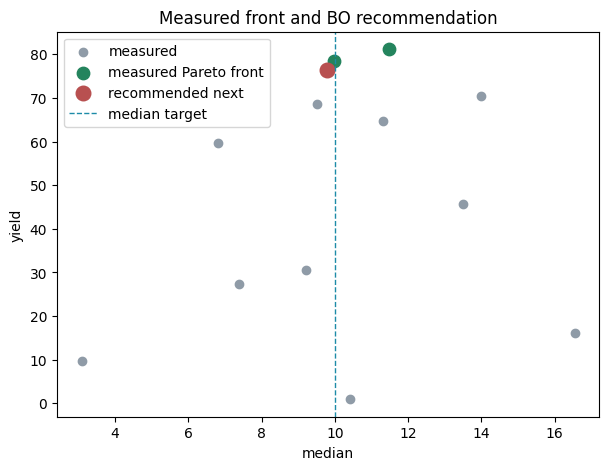

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(measured['median'], measured['yield'], color='#8f9ba7', label='measured')
ax.scatter(measured_front['median'], measured_front['yield'], color='#24845d', s=80, label='measured Pareto front')
next_row = ranked.iloc[0]
ax.scatter(next_row['predicted_median'], next_row['predicted_yield'], color='#b85050', s=110, label='recommended next')
ax.axvline(10, color='#1d8ba8', linestyle='--', linewidth=1, label='median target')
ax.set_xlabel('median')
ax.set_ylabel('yield')
ax.legend()
ax.set_title('Measured front and BO recommendation')
plt.show()